In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# 1. Membuat Dataset Dummy (Skenario: Umur dan Pendapatan)
np.random.seed(42)
umur = np.random.normal(loc=35, scale=5, size=200)
pendapatan = np.random.normal(loc=8, scale=2, size=200) # dalam jutaan

# Menyisipkan Outlier secara sengaja untuk simulasi UTS
umur_outliers = np.array([80, 85, 90]) 
pendapatan_outliers = np.array([25, 30, 35])

df = pd.DataFrame({
    'Umur': np.concatenate([umur, umur_outliers]),
    'Pendapatan': np.concatenate([pendapatan, pendapatan_outliers])
})

print("Info Dataset:")
display(df.info())
print(df.head())
print("\nStatistik Deskriptif Awal:")
display(df.describe())


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Umur        203 non-null    float64
 1   Pendapatan  203 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


None

        Umur  Pendapatan
0  37.483571    8.715575
1  34.308678    9.121569
2  38.238443   10.166102
3  42.615149   10.107604
4  33.829233    5.244661

Statistik Deskriptif Awal:


,Umur,Pendapatan
count,203.000000,203.000000
mean,35.538074,8.494322
std,7.646817,3.325375
min,21.901274,1.517465
25%,31.544805,6.800390
50%,35.065009,8.193992
75%,37.661254,9.506263
max,90.000000,35.000000


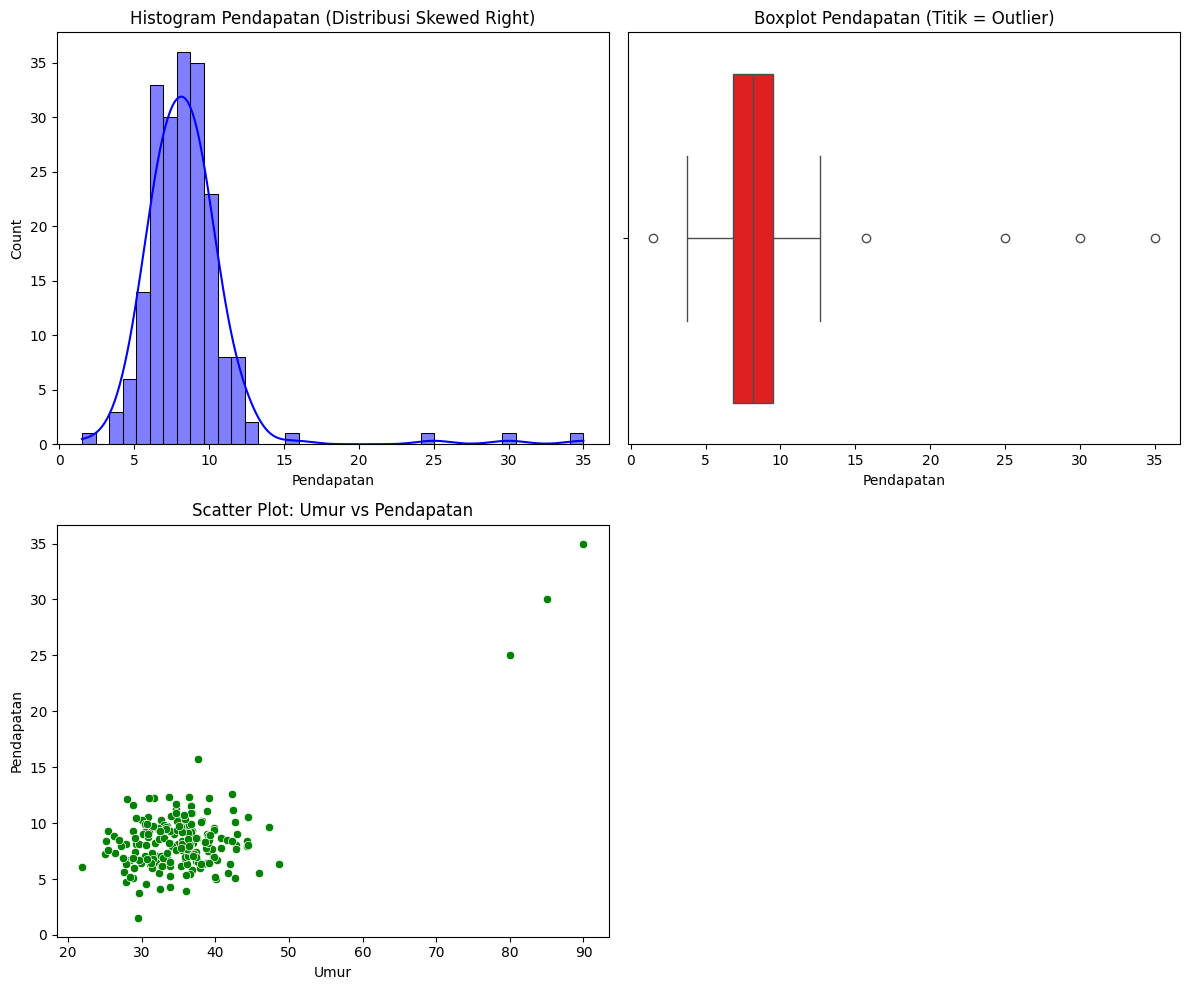

In [3]:
# 2. VISUALISASI DISTRIBUSI DAN OUTLIER
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# A. Histogram (Melihat Distribusi Data)
sns.histplot(df['Pendapatan'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Histogram Pendapatan (Distribusi Skewed Right)')

# B. Boxplot (Deteksi Outlier Univariate)
sns.boxplot(x=df['Pendapatan'], ax=axes[0, 1], color='red')
axes[0, 1].set_title('Boxplot Pendapatan (Titik = Outlier)')

# C. Scatter Plot (Bivariate Analysis)
sns.scatterplot(x='Umur', y='Pendapatan', data=df, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Scatter Plot: Umur vs Pendapatan')

# Kosongkan subplot terakhir agar rapi
axes[1, 1].axis('off') 

plt.tight_layout()
plt.show()

# Penjelasan singkat:
# Histogram menunjukkan ekor panjang ke kanan (karena ada gaji 30 jutaan).
# Boxplot mengonfirmasi bahwa nilai di atas ~14 juta adalah outlier.

In [4]:
# 3. MENGHAPUS OUTLIER DENGAN INTERQUARTILE RANGE (IQR)
def remove_outlier_iqr(df_in, col_name):
    Q1 = df_in[col_name].quantile(0.25)
    Q3 = df_in[col_name].quantile(0.75)
    IQR = Q3 - Q1
    
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    # Filter hanya data yang berada di rentang wajar
    df_out = df_in[(df_in[col_name] >= batas_bawah) & (df_in[col_name] <= batas_atas)]
    return df_out

# Proses pembersihan
df_clean = remove_outlier_iqr(df, 'Pendapatan')
df_clean = remove_outlier_iqr(df_clean, 'Umur')

print(f"Jumlah data awal: {len(df)}")
print(f"Jumlah data setelah dibersihkan: {len(df_clean)}")

Jumlah data awal: 203
Jumlah data setelah dibersihkan: 195


In [5]:
# 4. SKALA FITUR (FEATURE SCALING)
# Kita membandingkan StandardScaler dan MinMaxScaler

# Inisialisasi Scaler
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

df_scaled = df_clean.copy()

# A. Standardization (Fokus mengubah Mean ~ 0, Std ~ 1)
df_scaled[['Umur_Std', 'Pend_Std']] = std_scaler.fit_transform(df_clean[['Umur', 'Pendapatan']])

# B. Normalization (Fokus memampatkan rentang jadi 0.0 - 1.0)
df_scaled[['Umur_MinMax', 'Pend_MinMax']] = minmax_scaler.fit_transform(df_clean[['Umur', 'Pendapatan']])

print("Hasil Akhir Feature Scaling:")
display(df_scaled[['Umur', 'Umur_Std', 'Umur_MinMax', 'Pendapatan', 'Pend_Std', 'Pend_MinMax']].head())

# Kesimpulan Preprocessing:
# Data kini bebas outlier dan memiliki skala yang seragam, 
# sehingga aman untuk dimasukkan ke dalam algoritma Machine Learning.

Hasil Akhir Feature Scaling:


,Umur,Umur_Std,Umur_MinMax,Pendapatan,Pend_Std,Pend_MinMax
0,37.483571,0.624792,0.594607,8.715575,0.290187,0.559120
1,34.308678,-0.098130,0.442627,9.121569,0.510116,0.604855
2,38.238443,0.796676,0.630742,10.166102,1.075945,0.722521
3,42.615149,1.793251,0.840253,10.107604,1.044256,0.715931
4,33.829233,-0.207299,0.419676,5.244661,-1.590023,0.168124
